In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [10]:
# define the State
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percentage: float
    summary: str

In [11]:
def cal_str(state: BatsmanState) -> BatsmanState:
    sr = (state['runs'] / state['balls']) * 100
    return {'sr':sr}
def cal_bpb(state: BatsmanState) -> BatsmanState:
    bpb = state['balls'] / state['runs'] if state['runs'] != 0 else float('inf')
    return {'bpb':bpb}
def cal_boundary_percentage(state: BatsmanState) -> BatsmanState:
    total_boundaries = state['fours']*4 + state['sixes']*6
    boundary_percentage = (total_boundaries / state['runs']) * 100 if state['runs'] != 0 else 0
    return {'boundary_percentage':boundary_percentage}
def generate_summary(state: BatsmanState) -> BatsmanState:
    summary = (f"Batsman scored {state['runs']} runs off {state['balls']} balls, "
               f"with a strike rate of {state['sr']:.2f}, "
               f"balls per run of {state['bpb']:.2f}, "
               f"and a boundary percentage of {state['boundary_percentage']:.2f}%.")
    return {'summary':summary}


In [12]:
# define the StateGraph
graph = StateGraph(BatsmanState)

graph.add_node("cal_str",cal_str)
graph.add_node("cal_bpb",cal_bpb)
graph.add_node("cal_boundary_percentage",cal_boundary_percentage)
graph.add_node("generate_summary",generate_summary)

In [13]:
# add edges to define the flow
graph.add_edge(START, "cal_str")
graph.add_edge(START, "cal_bpb")
graph.add_edge(START, "cal_boundary_percentage")
graph.add_edge("cal_boundary_percentage", "generate_summary")
graph.add_edge('cal_str', 'generate_summary')
graph.add_edge('cal_bpb', 'generate_summary')
graph.add_edge('generate_summary', END)


In [14]:
workflow = graph.compile()


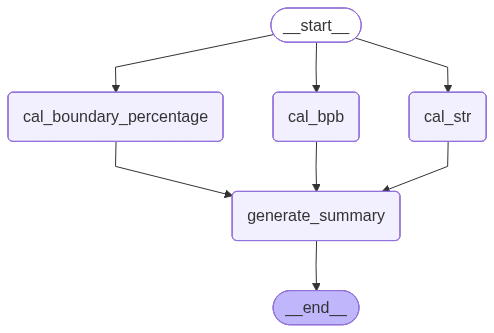

In [15]:
workflow

In [16]:
initial_state = {'runs': 100, 'balls': 60, 'fours': 10, 'sixes': 5}
final_state = workflow.invoke(initial_state)

In [17]:
final_state  # This will print the summary of the batsman's performance

{'runs': 100,
 'balls': 60,
 'fours': 10,
 'sixes': 5,
 'sr': 166.66666666666669,
 'bpb': 0.6,
 'boundary_percentage': 70.0,
 'summary': 'Batsman scored 100 runs off 60 balls, with a strike rate of 166.67, balls per run of 0.60, and a boundary percentage of 70.00%.'}